# 🚀 Pipeline final : Dune Client + Binance + EDA

**Source de données :**
- Uniswap : Dune query #7388177 via `dune-client` (volumes USD réels, propres)
- Binance : data.binance.vision (prix off-chain de référence)

## 0. Installation et setup

In [1]:
# Installer dune-client (pas dispo par défaut sur Kaggle)
!pip install -q dune-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
gcsfs 2025.3.0 requires 

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request, urllib.error, zipfile
from pathlib import Path
from scipy import stats
from kaggle_secrets import UserSecretsClient
from dune_client.client import DuneClient

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
sns.set_palette("husl")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

WORK = Path("/kaggle/working"); WORK.mkdir(exist_ok=True)
OUT_BIN = WORK / "binance_csv"; OUT_BIN.mkdir(exist_ok=True)

# Constantes
QUERY_ID = 7388177
START_DT = "2021-05-01 00:00:00"
END_DT   = "2024-02-01 00:00:00"

# API keys depuis Kaggle Secrets
DUNE_API_KEY = UserSecretsClient().get_secret("DUNE_API_KEY")

print(f"✅ Setup OK")
print(f"   Dune Query ID : {QUERY_ID}")
print(f"   Période       : {START_DT} → {END_DT}")
print(f"   API key       : {DUNE_API_KEY[:4]}... ({len(DUNE_API_KEY)} chars)")

✅ Setup OK
   Dune Query ID : 7388177
   Période       : 2021-05-01 00:00:00 → 2024-02-01 00:00:00
   API key       : IZo9... (32 chars)


## 1. Téléchargement Uniswap via Dune Client (~5 sec)

`get_latest_result()` récupère le **dernier résultat exécuté** de la query.
Comme tu as déjà run la query sur Dune, le résultat est en cache → instantané.

In [3]:
dune = DuneClient(DUNE_API_KEY)
print(f"⏳ Récupération des résultats de la query {QUERY_ID}...")

query_result = dune.get_latest_result(QUERY_ID)

# Conversion du résultat Dune en DataFrame pandas
uniswap = pd.DataFrame(query_result.result.rows)
print(f"\n✅ {len(uniswap):,} lignes récupérées depuis Dune")
print(f"\n📊 Colonnes disponibles:\n   {list(uniswap.columns)}")
uniswap.head(3)

⏳ Récupération des résultats de la query 7388177...

✅ 24,026 lignes récupérées depuis Dune

📊 Colonnes disponibles:
   ['avg_swap_size_usd', 'fees_usd', 'max_swap_size_usd', 'median_swap_size_usd', 'n_swaps', 'p95_swap_size_usd', 'p99_swap_size_usd', 'timestamp', 'unique_takers', 'volume_buy_weth_usd', 'volume_sell_weth_usd', 'volume_usd', 'vwap_eth_usd']


,avg_swap_size_usd,fees_usd,max_swap_size_usd,median_swap_size_usd,n_swaps,p95_swap_size_usd,p99_swap_size_usd,timestamp,unique_takers,volume_buy_weth_usd,volume_sell_weth_usd,volume_usd,vwap_eth_usd
0,120.0306,0.0600,120.0306,120.0306,1,120.0306,120.0306,2021-05-05 22:00:00.000 UTC,1,0.0000,120.0306,120.0306,"3,429.4469"
1,718.3633,1.7959,"2,023.7236",510.6956,5,"2,023.7236","2,023.7236",2021-05-05 23:00:00.000 UTC,1,876.6076,"2,715.2090","3,591.8166","3,525.7667"
2,"1,579.1596",7.1062,"3,878.6110","1,769.9052",9,"3,878.6110","3,878.6110",2021-05-06 00:00:00.000 UTC,5,"5,949.1228","8,263.3138","14,212.4366","3,526.3272"


In [4]:
# Conversion des types
uniswap["timestamp"] = pd.to_datetime(uniswap["timestamp"], utc=True)

# Toutes les colonnes numériques en float64
numeric_cols = [c for c in uniswap.columns if c != "timestamp"]
for c in numeric_cols:
    uniswap[c] = pd.to_numeric(uniswap[c], errors="coerce").astype("float64")

# Tri et dédup
uniswap = uniswap.sort_values("timestamp").drop_duplicates("timestamp").reset_index(drop=True)

# Sauvegarde brute
uniswap.to_parquet(WORK / "uniswap_dune.parquet", index=False)

# Vérification critique
print(f"📊 Diagnostic Uniswap (% > 0):")
key_cols = ["volume_usd", "fees_usd", "n_swaps"]
for c in key_cols:
    if c in uniswap.columns:
        pct = (uniswap[c] > 0).mean() * 100
        med = uniswap[c].median()
        mx = uniswap[c].max()
        tot = uniswap[c].sum()
        print(f"   {c:<20} % > 0: {pct:>5.1f}%  median={med:>15,.2f}  max={mx:>15,.2f}  total={tot:>18,.0f}")

print(f"\n   Période: {uniswap['timestamp'].min()} → {uniswap['timestamp'].max()}")

📊 Diagnostic Uniswap (% > 0):
   volume_usd           % > 0: 100.0%  median=  12,044,713.64  max= 396,045,806.08  total=   428,696,007,410
   fees_usd             % > 0: 100.0%  median=       6,022.36  max=     198,022.90  total=       214,348,004
   n_swaps              % > 0: 100.0%  median=         219.00  max=       1,816.00  total=         5,964,951

   Période: 2021-05-05 22:00:00+00:00 → 2024-01-31 23:00:00+00:00


## 2. Téléchargement Binance ETHUSDT 1h (~5 min)

In [5]:
months = (
    [(2021, m) for m in range(5, 13)]
    + [(y, m) for y in [2022, 2023] for m in range(1, 13)]
    + [(2024, 1)]
)
base_url = "https://data.binance.vision/data/spot/monthly/klines/ETHUSDT/1h"

print(f"⏳ Téléchargement de {len(months)} mois Binance...")
for year, month in months:
    fname = f"ETHUSDT-1h-{year}-{month:02d}.zip"
    csv_name = fname.replace(".zip", ".csv")
    if (OUT_BIN / csv_name).exists():
        continue
    try:
        urllib.request.urlretrieve(f"{base_url}/{fname}", OUT_BIN / fname)
        with zipfile.ZipFile(OUT_BIN / fname, "r") as z:
            z.extractall(OUT_BIN)
        (OUT_BIN / fname).unlink()
    except urllib.error.HTTPError as e:
        print(f"  ✗ {fname} indisponible (HTTP {e.code})")

print(f"✅ {len(list(OUT_BIN.glob('*.csv')))} fichiers CSV")

⏳ Téléchargement de 33 mois Binance...
✅ 33 fichiers CSV


In [6]:
cols = ["open_time","open","high","low","close","volume","close_time","quote_vol",
        "n_trades","taker_buy_base","taker_buy_quote","ignore"]

dfs = []
for csv_file in sorted(OUT_BIN.glob("*.csv")):
    first_row = pd.read_csv(csv_file, nrows=1, header=None)
    has_header = isinstance(first_row.iloc[0, 0], str) and not first_row.iloc[0, 0].isdigit()
    df_csv = pd.read_csv(csv_file, header=0 if has_header else None, names=cols)
    dfs.append(df_csv)

binance = pd.concat(dfs, ignore_index=True)
binance["timestamp"] = pd.to_datetime(binance["open_time"].astype(int), unit="ms", utc=True)
binance = binance.sort_values("timestamp").drop_duplicates("timestamp").reset_index(drop=True)
binance = binance[["timestamp", "open", "high", "low", "close", "volume", "n_trades"]]

for c in ["open", "high", "low", "close", "volume"]:
    binance[c] = pd.to_numeric(binance[c], errors="coerce").astype("float64")
binance["n_trades"] = pd.to_numeric(binance["n_trades"], errors="coerce").astype("Int64")

start_ts = pd.Timestamp(START_DT, tz="UTC")
end_ts = pd.Timestamp(END_DT, tz="UTC")
binance = binance[(binance["timestamp"] >= start_ts) & (binance["timestamp"] < end_ts)].reset_index(drop=True)

binance.to_parquet(WORK / "binance.parquet", index=False)
print(f"✅ Binance: {len(binance):,} lignes du {binance['timestamp'].min()} au {binance['timestamp'].max()}")

✅ Binance: 24,137 lignes du 2021-05-01 00:00:00+00:00 au 2024-01-31 23:00:00+00:00


## 3. Alignement temporel

In [7]:
binance_h = binance.set_index("timestamp")[["close", "volume", "n_trades"]].rename(
    columns={"close": "binance_price",
             "volume": "binance_volume",
             "n_trades": "binance_n_trades"}
)

# Renommer les colonnes Uniswap (préfixer par "uniswap_")
uniswap_h = uniswap.set_index("timestamp").copy()
rename_map = {c: f"uniswap_{c}" for c in uniswap_h.columns if not c.startswith("uniswap_")}
uniswap_h = uniswap_h.rename(columns=rename_map)

# Inner join sur l'index horaire
df = binance_h.join(uniswap_h, how="inner")
df = df.dropna(subset=["binance_price"])

# Si on a un VWAP Uniswap, on l'utilise comme prix de référence on-chain
if "uniswap_vwap_eth_usd" in df.columns:
    df["uniswap_price"] = df["uniswap_vwap_eth_usd"]
elif "uniswap_avg_price" in df.columns:
    df["uniswap_price"] = df["uniswap_avg_price"]
else:
    print("⚠️  Pas de colonne de prix Uniswap → on utilisera Binance pour les deux")
    df["uniswap_price"] = df["binance_price"]

df["price_deviation_bps"] = (
    (df["uniswap_price"] - df["binance_price"]) / df["binance_price"] * 10_000
)

print(f"✅ Alignement OK: {len(df):,} heures")
print(f"   Période: {df.index.min()} → {df.index.max()}")
print(f"\n📊 Diagnostic post-alignement:")
for c in ["uniswap_volume_usd", "uniswap_fees_usd", "uniswap_n_swaps"]:
    if c in df.columns:
        pct = (df[c] > 0).mean() * 100
        med = df[c].median()
        print(f"   {c:<25} % > 0: {pct:>5.1f}%  median={med:>15,.2f}")

✅ Alignement OK: 24,019 heures
   Période: 2021-05-05 22:00:00+00:00 → 2024-01-31 23:00:00+00:00

📊 Diagnostic post-alignement:
   uniswap_volume_usd        % > 0: 100.0%  median=  12,044,402.00
   uniswap_fees_usd          % > 0: 100.0%  median=       6,022.20
   uniswap_n_swaps           % > 0: 100.0%  median=         219.00


## 4. Sanity check des prix

📊 Ratio Uniswap/Binance:
   median=1.0002 | mean=1.0002 | std=0.0055
   ✅ OK


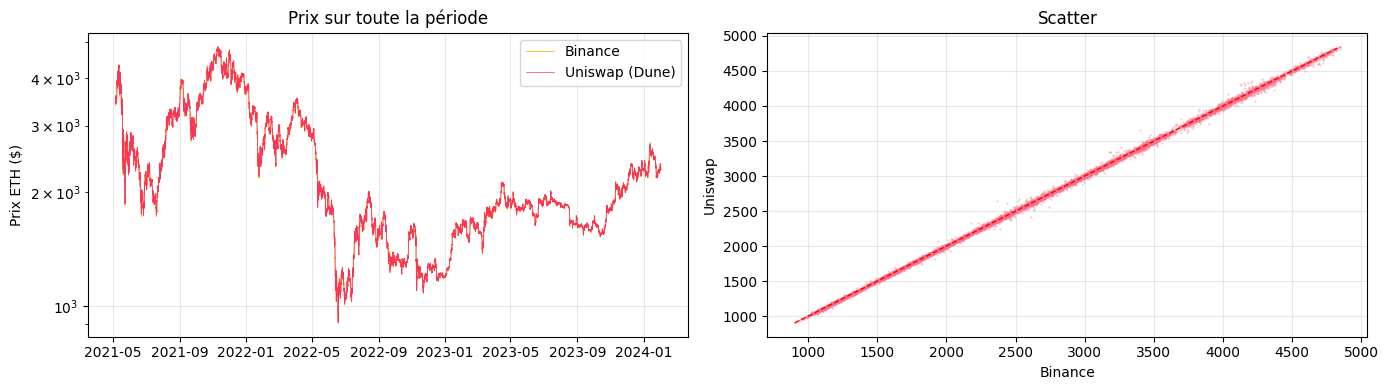

In [8]:
ratio = df["uniswap_price"] / df["binance_price"]
print(f"📊 Ratio Uniswap/Binance:")
print(f"   median={ratio.median():.4f} | mean={ratio.mean():.4f} | std={ratio.std():.4f}")
print(f"   ✅ OK" if abs(ratio.median() - 1.0) < 0.05 else "⚠️ écart suspect")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(df.index, df["binance_price"], label="Binance", lw=0.6, color="#F0B90B")
ax[0].plot(df.index, df["uniswap_price"], label="Uniswap (Dune)", lw=0.6, color="#FF007A", alpha=0.7)
ax[0].set_title("Prix sur toute la période"); ax[0].legend(); ax[0].set_yscale("log")
ax[0].set_ylabel("Prix ETH ($)")

ax[1].scatter(df["binance_price"], df["uniswap_price"], s=0.5, alpha=0.3)
lims = [df["binance_price"].min(), df["binance_price"].max()]
ax[1].plot(lims, lims, "r--", lw=1)
ax[1].set_xlabel("Binance"); ax[1].set_ylabel("Uniswap"); ax[1].set_title("Scatter")
plt.tight_layout(); plt.show()

## 5. Nettoyage + features dérivées

In [9]:
mask_valid = (
    (df["uniswap_price"] > 100) & (df["uniswap_price"] < 100_000) &
    (df["binance_price"] > 100) & (df["binance_price"] < 100_000)
)
n_removed = (~mask_valid).sum()
df = df[mask_valid].copy()
print(f"   Lignes corrompues retirées : {n_removed}")

# Recalcul propre de la déviation
df["price_deviation_bps"] = (
    (df["uniswap_price"] - df["binance_price"]) / df["binance_price"] * 10_000
)

# Winsorize p0.5/p99.5
dev_low, dev_high = df["price_deviation_bps"].quantile([0.005, 0.995])
df["price_deviation_bps_raw"] = df["price_deviation_bps"]
df["price_deviation_bps"] = df["price_deviation_bps"].clip(dev_low, dev_high)

# Volatilité réalisée et régimes
df["log_ret"] = np.log(df["binance_price"] / df["binance_price"].shift())
df["vol_24h"] = df["log_ret"].rolling(24).std() * np.sqrt(24)
df["vol_7d"] = df["log_ret"].rolling(168).std() * np.sqrt(168 * 365 / 24)

vol_low, vol_high = df["vol_7d"].quantile([0.33, 0.67])
df["regime"] = pd.cut(df["vol_7d"], bins=[-np.inf, vol_low, vol_high, np.inf],
                      labels=["calm", "normal", "stressed"])

print(f"\n✅ Final : {len(df):,} lignes × {df.shape[1]} colonnes")
print(f"   Régimes:")
print(df["regime"].value_counts(normalize=True).round(3).to_string())

   Lignes corrompues retirées : 0

✅ Final : 24,019 lignes × 22 colonnes
   Régimes:
regime
normal     0.3400
calm       0.3300
stressed   0.3300


## 6. EDA — distribution de la déviation

📊 Stats déviation:
count   24,019.0000
mean         1.9700
std         49.4700
min       -195.2700
1%        -154.0300
5%         -77.2600
25%        -17.7800
50%          2.1000
75%         22.0900
95%         79.0100
99%        161.5700
max        210.5200

   Skew: 0.052 | Kurtosis: 4.060


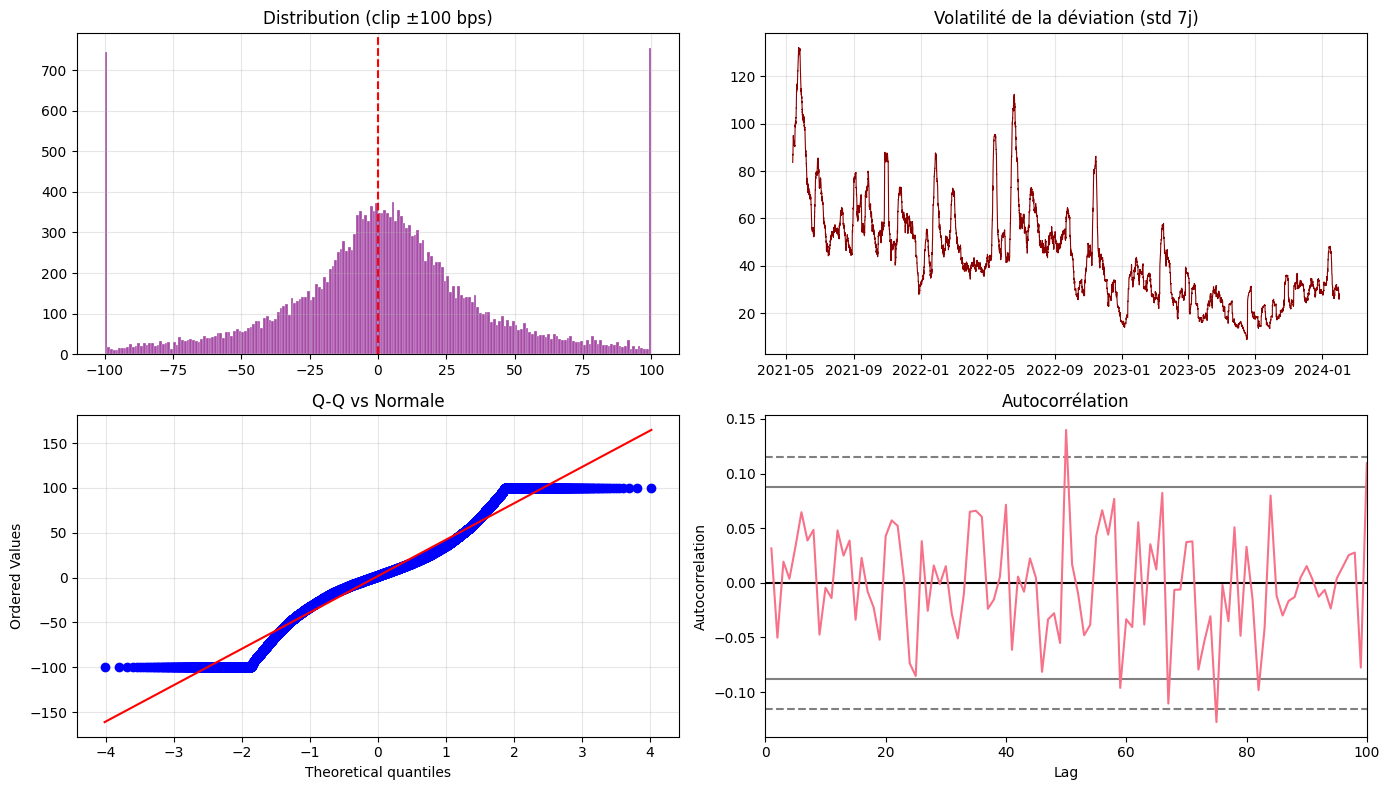

In [10]:
dev = df["price_deviation_bps"]
print(f"📊 Stats déviation:")
print(dev.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2).to_string())
print(f"\n   Skew: {stats.skew(dev.dropna()):.3f} | Kurtosis: {stats.kurtosis(dev.dropna()):.3f}")

fig, ax = plt.subplots(2, 2, figsize=(14, 8))
ax[0,0].hist(dev.clip(-100, 100), bins=200, alpha=0.7, color="purple", edgecolor="white", linewidth=0.3)
ax[0,0].axvline(0, color="red", ls="--"); ax[0,0].set_title("Distribution (clip ±100 bps)")

ax[0,1].plot(dev.index, dev.rolling(168).std(), color="darkred", lw=0.8)
ax[0,1].set_title("Volatilité de la déviation (std 7j)")

stats.probplot(dev.dropna().clip(-100, 100), dist="norm", plot=ax[1,0])
ax[1,0].set_title("Q-Q vs Normale")

from pandas.plotting import autocorrelation_plot
autocorrelation_plot(dev.dropna().iloc[:500], ax=ax[1,1])
ax[1,1].set_xlim(0, 100); ax[1,1].set_title("Autocorrélation")
plt.tight_layout(); plt.show()

## 7. EDA — activité du pool (vraies valeurs Dune)

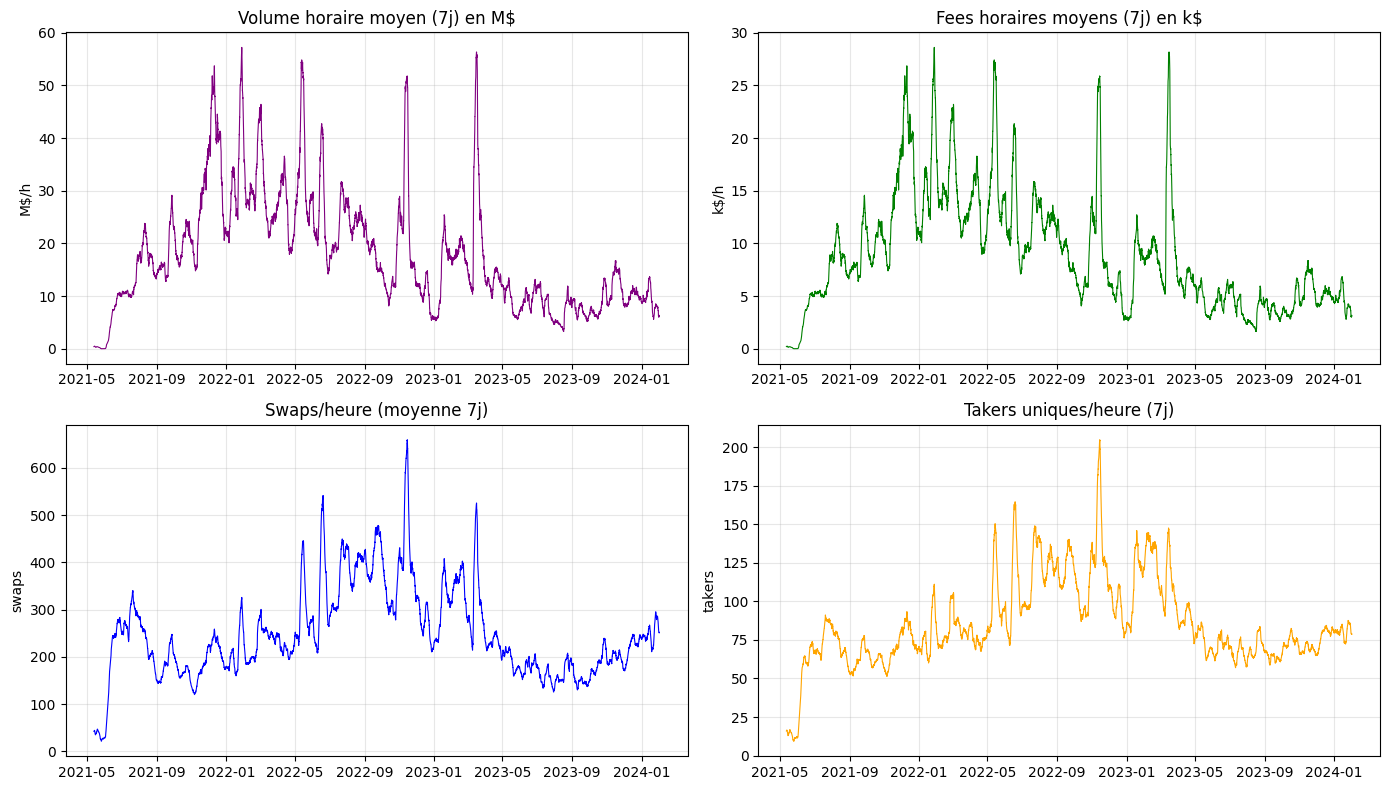

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

ax[0,0].plot(df.index, df["uniswap_volume_usd"].rolling(168).mean() / 1e6, color="purple", lw=0.8)
ax[0,0].set_title("Volume horaire moyen (7j) en M$"); ax[0,0].set_ylabel("M$/h")

ax[0,1].plot(df.index, df["uniswap_fees_usd"].rolling(168).mean() / 1e3, color="green", lw=0.8)
ax[0,1].set_title("Fees horaires moyens (7j) en k$"); ax[0,1].set_ylabel("k$/h")

ax[1,0].plot(df.index, df["uniswap_n_swaps"].rolling(168).mean(), color="blue", lw=0.8)
ax[1,0].set_title("Swaps/heure (moyenne 7j)"); ax[1,0].set_ylabel("swaps")

# Si on a unique_takers
if "uniswap_unique_takers" in df.columns:
    ax[1,1].plot(df.index, df["uniswap_unique_takers"].rolling(168).mean(), color="orange", lw=0.8)
    ax[1,1].set_title("Takers uniques/heure (7j)"); ax[1,1].set_ylabel("takers")
elif "uniswap_avg_swap_size_usd" in df.columns:
    ax[1,1].plot(df.index, df["uniswap_avg_swap_size_usd"].rolling(168).mean() / 1e3, color="orange", lw=0.8)
    ax[1,1].set_title("Taille moyenne swap (7j) en k$"); ax[1,1].set_ylabel("k$")
plt.tight_layout(); plt.show()

## 8. EDA — corrélations

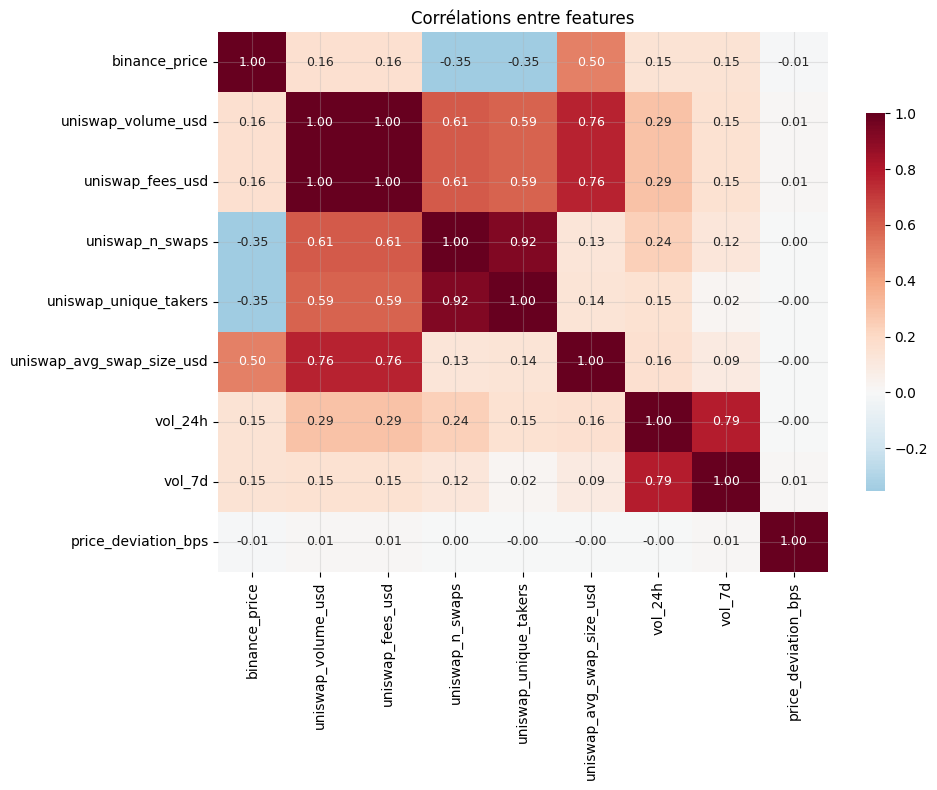

In [12]:
features = [c for c in [
    "binance_price", "uniswap_volume_usd", "uniswap_fees_usd",
    "uniswap_n_swaps", "uniswap_unique_takers", "uniswap_avg_swap_size_usd",
    "vol_24h", "vol_7d", "price_deviation_bps"
] if c in df.columns]

corr = df[features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"shrink": 0.7}, annot_kws={"size": 9})
ax.set_title("Corrélations entre features")
plt.tight_layout(); plt.show()

## 9. EDA — analyse par régime

In [13]:
print("📊 Stats par régime:\n")
agg_dict = {
    "nb_heures": ("binance_price", "count"),
    "dev_mean_bps": ("price_deviation_bps", lambda x: x.abs().mean()),
    "dev_p95_bps": ("price_deviation_bps", lambda x: x.abs().quantile(0.95)),
    "volume_med": ("uniswap_volume_usd", "median"),
    "fees_med": ("uniswap_fees_usd", "median"),
    "n_swaps_med": ("uniswap_n_swaps", "median"),
}
metrics = df.groupby("regime", observed=True).agg(**agg_dict).round(2)
print(metrics.to_string())

📊 Stats par régime:

          nb_heures  dev_mean_bps  dev_p95_bps      volume_med   fees_med  n_swaps_med
regime                                                                                
calm           7871       17.4300      52.8400  6,272,217.5700 3,136.1100     188.0000
normal         8109       31.1500      94.4300 14,670,269.5000 7,335.1300     225.0000
stressed       7871       49.0200     150.8400 17,034,009.0800 8,517.0000     255.0000


## 10. Génération des 11 fenêtres rolling (Xu & Brini)

In [14]:
WINDOW_TRAIN, WINDOW_TEST = 7500, 1500
windows = []
start = 0
while start + WINDOW_TRAIN + WINDOW_TEST <= len(df):
    windows.append({
        "id": len(windows) + 1,
        "train_start": df.index[start],
        "train_end": df.index[start + WINDOW_TRAIN - 1],
        "test_start": df.index[start + WINDOW_TRAIN],
        "test_end": df.index[start + WINDOW_TRAIN + WINDOW_TEST - 1],
    })
    start += WINDOW_TEST

windows_df = pd.DataFrame(windows)
print(f"📅 {len(windows_df)} fenêtres rolling:\n")
print(windows_df.to_string(index=False))

windows_df.to_parquet(WORK / "rolling_windows.parquet", index=False)

📅 11 fenêtres rolling:

 id               train_start                 train_end                test_start                  test_end
  1 2021-05-05 22:00:00+00:00 2022-03-14 15:00:00+00:00 2022-03-14 16:00:00+00:00 2022-05-16 03:00:00+00:00
  2 2021-07-07 10:00:00+00:00 2022-05-16 03:00:00+00:00 2022-05-16 04:00:00+00:00 2022-07-17 15:00:00+00:00
  3 2021-09-08 02:00:00+00:00 2022-07-17 15:00:00+00:00 2022-07-17 16:00:00+00:00 2022-09-18 03:00:00+00:00
  4 2021-11-09 16:00:00+00:00 2022-09-18 03:00:00+00:00 2022-09-18 04:00:00+00:00 2022-11-19 15:00:00+00:00
  5 2022-01-11 04:00:00+00:00 2022-11-19 15:00:00+00:00 2022-11-19 16:00:00+00:00 2023-01-21 03:00:00+00:00
  6 2022-03-14 16:00:00+00:00 2023-01-21 03:00:00+00:00 2023-01-21 04:00:00+00:00 2023-03-24 16:00:00+00:00
  7 2022-05-16 04:00:00+00:00 2023-03-24 16:00:00+00:00 2023-03-24 17:00:00+00:00 2023-05-26 04:00:00+00:00
  8 2022-07-17 16:00:00+00:00 2023-05-26 04:00:00+00:00 2023-05-26 05:00:00+00:00 2023-07-27 16:00:00+00:00
  9 

## 11. Sauvegarde finale

In [15]:
df.to_parquet(WORK / "aligned_data.parquet")

print(f"📋 RÉCAPITULATIF FINAL\n")
print(f"   Période              : {df.index.min()} → {df.index.max()}")
print(f"   Nombre d'heures      : {len(df):,}")
print(f"   Heures complètes     : {df.dropna().shape[0]:,}")
print(f"   Colonnes             : {df.shape[1]}")
print(f"   Fenêtres rolling     : {len(windows_df)}")
print(f"\n   Volume Uniswap total : ${df['uniswap_volume_usd'].sum() / 1e9:,.2f} B")
print(f"   Fees Uniswap total   : ${df['uniswap_fees_usd'].sum() / 1e6:,.2f} M")

print(f"\n📁 Fichiers dans /kaggle/working/:")
for f in sorted(WORK.glob("*.parquet")):
    print(f"   • {f.name}  ({f.stat().st_size / 1e6:.2f} MB)")

print(f"\n✅ Pipeline complet OK — données prêtes pour l'étape RL")

📋 RÉCAPITULATIF FINAL

   Période              : 2021-05-05 22:00:00+00:00 → 2024-01-31 23:00:00+00:00
   Nombre d'heures      : 24,019
   Heures complètes     : 23,851
   Colonnes             : 22
   Fenêtres rolling     : 11

   Volume Uniswap total : $428.57 B
   Fees Uniswap total   : $214.29 M

📁 Fichiers dans /kaggle/working/:
   • aligned_data.parquet  (4.59 MB)
   • binance.parquet  (1.16 MB)
   • rolling_windows.parquet  (0.00 MB)
   • uniswap_dune.parquet  (2.66 MB)

✅ Pipeline complet OK — données prêtes pour l'étape RL
